# 02 · What makes the trajectory features work?

**NFL Big Data Bowl 2026 — Prediction · Feature research completion gate**

The bank contains **7,999 candidates in 20 families**. The central question is whether their signals improve the official metric under the same estimator and honest chronological validation. Follow the evidence from a 64-feature reference through nested additions, wider budgets, family removals, and availability tests.

The reserved 48-game holdout is unscored. Development results are not a leaderboard claim. The final section retains an owner-controlled export; automated review never enables it.

**Research milestone:** all 15 feature-gate criteria now pass. The feature definitions and refit columns are frozen. Final refitting and the reserved-holdout evaluation remain the next phase.

In [1]:
import io
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from IPython.display import Image, Markdown, display

from nfl_trajectory.research import load_evidence, load_research_report

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
PUBLISHED = ROOT / "docs/results"
feature_summary, selection, evidence_label = load_evidence(ROOT)


def extra_report(local, published):
    path = ROOT / "artifacts" / local
    if not path.is_file():
        path = PUBLISHED / published
    if not path.is_file():
        return None
    result = json.loads(path.read_text())
    if result.get("status") != "passed" or result.get("holdout_evaluation") != "not_run":
        raise ValueError("A completed report with an unscored holdout is required.")
    return result


def static(figure):
    buffer = io.BytesIO()
    figure.savefig(buffer, format="png", dpi=150, bbox_inches="tight")
    plt.close(figure)
    display(Image(data=buffer.getvalue()))


def interactive(figure):
    figure.update_layout(template="plotly_white", font={"size": 13})
    display({"application/vnd.plotly.v1+json": json.loads(figure.to_json())}, raw=True)


research = importance = None
if (ROOT / "artifacts/research/report/summary.json").is_file() or (
    PUBLISHED / "feature_research.json"
).is_file():
    research, importance, research_label = load_research_report(ROOT)
    display(Markdown(f"**Research evidence:** {research_label}"))
probe = extra_report("nonlinear_probe/summary.json", "feature_probe.json")
ablation = extra_report("feature_ablation/summary.json", "feature_ablation.json")
budget = extra_report("feature_budget/summary.json", "feature_budget.json")
joint = extra_report("joint_linear/summary.json", "feature_joint.json")
inference = extra_report("research/inference/summary.json", "feature_inference.json")
input_failure = extra_report(
    "research/inference_before_fallback.json", "feature_input_failure.json"
)
attribution = extra_report("feature_attribution/summary.json", "feature_attribution.json")
gateway = extra_report("research/gateway/summary.json", "feature_gateway.json")
tree = extra_report("research/tree/summary.json", "feature_tree.json")
wide_ablation = extra_report("wide_ablation/summary.json", "feature_wide_ablation.json")
simplification = extra_report("simplification/summary.json", "feature_simplification.json")
gate = extra_report("research/gate/summary.json", "feature_gate.json")
diagnostics = extra_report("research/gate/diagnostics.json", "feature_diagnostics.json")
display(
    pd.DataFrame(
        [
            {"Evidence": name, "Available": value is not None}
            for name, value in [
                ("Candidate research", research),
                ("Fixed estimator comparisons", probe),
                ("Strict removals", ablation),
                ("Width search", budget),
                ("Joint linear fit", joint),
                ("Raw inference", inference),
                ("Wide attribution", attribution),
                ("Gateway", gateway),
                ("Portable tree", tree),
                ("Current wide group refits", wide_ablation),
                ("Combined feature omission", simplification),
                ("Completion decision", gate),
            ]
        ]
    )
)
if tree and diagnostics:
    display(
        Markdown(
            "**Verified shallow tree predictor** · "
            f"**{tree['retained_features']:,} actually used features** · "
            f"**{diagnostics['metrics']['coordinate_rmse_yards']:.5f} coordinate RMSE**"
        )
    )
    display(pd.Series(diagnostics["metrics"], name="Current development diagnostics").round(5))
if gate:
    display(Markdown(f"**Feature completion gate: {gate['feature_gate'].upper()}**"))
if diagnostics:
    comparison = diagnostics["controlled_comparison"]
    display(
        Markdown(
            f"**Feature improvement with estimator settings fixed: "
            f"{comparison['feature_gain_percent']:.2f}%.** "
            f"Landing features: {comparison['baseline_coordinate_rmse_yards']:.5f} RMSE; "
            f"engineered representation: {comparison['engineered_coordinate_rmse_yards']:.5f}."
        )
    )
    display(
        pd.Series(
            comparison["paired_delta_ci95_yards"],
            index=["lower", "upper"],
            name="Paired 95% interval for RMSE change (yards)",
        )
    )

**Research evidence:** Verified local feature research

,Evidence,Available
0,Candidate research,True
1,Fixed estimator comparisons,True
2,Strict removals,True
3,Width search,True
4,Joint linear fit,True
5,Raw inference,True
6,Wide attribution,True
7,Gateway,True
8,Portable tree,True
9,Current wide group refits,True


**Verified shallow tree predictor** · **953 actually used features** · **0.68805 coordinate RMSE**

coordinate_rmse_yards            0.68805
ade_frame_weighted_yards         0.57073
ade_trajectory_weighted_yards    0.44419
fde_trajectory_weighted_yards    1.02862
p95_displacement_yards           2.06102
coordinate_mae_yards             0.36267
Name: Current development diagnostics, dtype: float64

**Feature completion gate: CLOSED**

**Feature improvement with estimator settings fixed: 14.12%.** Landing features: 0.80120 RMSE; engineered representation: 0.68805.

lower   -0.127799
upper   -0.099733
Name: Paired 95% interval for RMSE change (yards), dtype: float64

## 1 · Attribute gains to the features with estimator settings fixed

Every nonlinear comparison uses two residual regressors: **100 iterations, depth 4, at most 15 leaves, learning rate 0.07, minimum leaf size 60, L2 penalty 1, and 63 bins**. Early stopping is disabled so a random frame split cannot enter training. The physical baseline is refitted within each training fold.

The landing reference, engineered core, context, representations, and their union use identical rows and settings. Independent noise columns are a negative control and never enter feature selection. Comparing these rows isolates representation gains at this fixed capacity; comparing a linear score with a tree score would also change the estimator.

,representation,feature_count,coordinate_rmse_yards,feature_gain_percent,delta_vs_landing_ci95
0,Combined engineered representation,250,0.72802,9.13398,"[-0.08341849134054938, -0.06294552376324578]"
1,Core plus learned/geometric representations,192,0.73827,7.85453,"[-0.07189206048722872, -0.05423168703958256]"
2,Core plus contextual features,186,0.74014,7.62050,"[-0.07081852821304872, -0.051081916849841494]"
3,Core plus independent noise,192,0.76915,3.99984,"[-0.04017201163285998, -0.023955115689822414]"
4,Engineered motion and geometry,128,0.76915,3.99984,"[-0.04017201163285998, -0.023955115689822414]"
5,Landing reference,64,0.80120,0.00000,"[0.0, 0.0]"


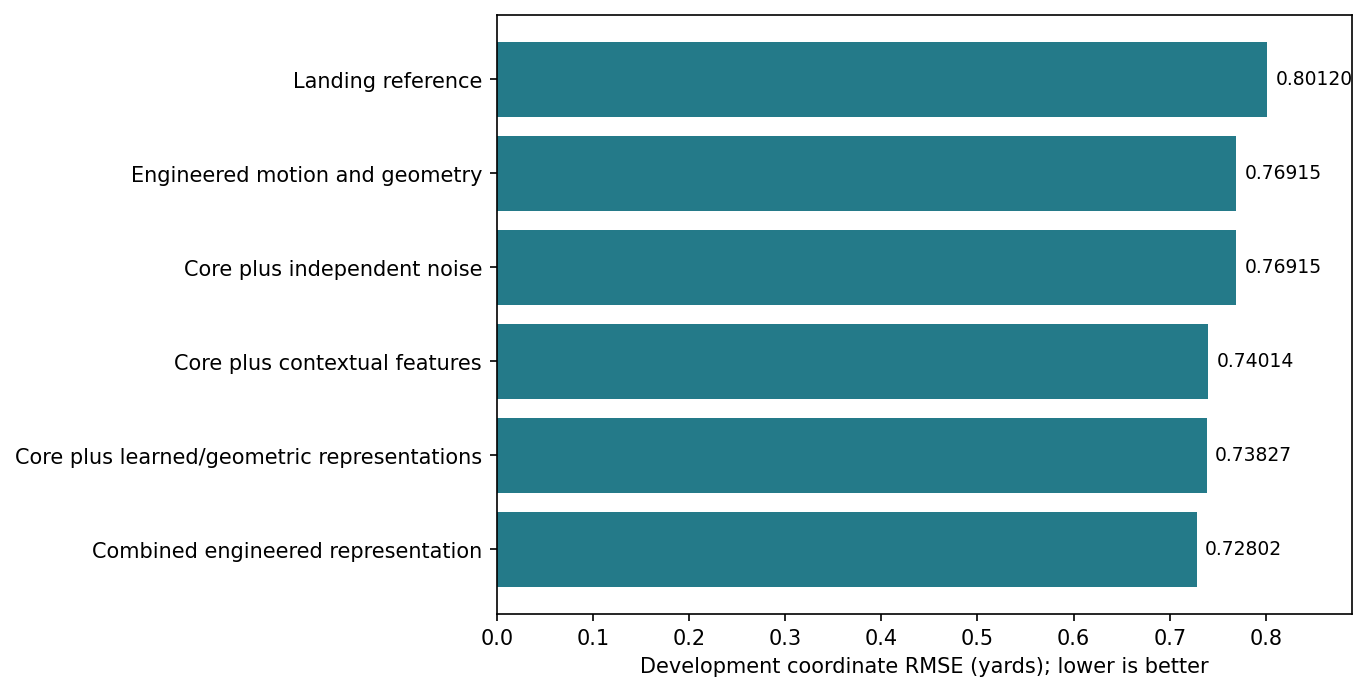

**Selected on inner folds:** all_engineered

In [2]:
if probe:
    scores = pd.DataFrame(probe["models"])
    scores = scores.loc[~scores.model.eq("constant_velocity")].copy()
    reference = scores.loc[scores.model.eq("landing_features"), "coordinate_rmse_yards"].iloc[0]
    scores["feature_gain_percent"] = 100 * (1 - scores.coordinate_rmse_yards / reference)
    labels = {
        "landing_features": "Landing reference",
        "engineered_core": "Engineered motion and geometry",
        "core_plus_noise": "Core plus independent noise",
        "core_plus_context": "Core plus contextual features",
        "core_plus_representation": "Core plus learned/geometric representations",
        "all_engineered": "Combined engineered representation",
    }
    scores["representation"] = scores.model.map(labels)
    display(
        scores[
            [
                "representation",
                "feature_count",
                "coordinate_rmse_yards",
                "feature_gain_percent",
                "delta_vs_landing_ci95",
            ]
        ].round(5)
    )
    interactive(
        px.bar(
            scores,
            x="coordinate_rmse_yards",
            y="representation",
            orientation="h",
            color="feature_gain_percent",
            title="Same estimator, different features",
            labels={"coordinate_rmse_yards": "Development RMSE (yards)"},
        )
    )
    fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
    bars = ax.barh(scores.representation, scores.coordinate_rmse_yards, color="#247A89")
    ax.bar_label(bars, fmt="%.5f", padding=4, fontsize=9)
    ax.set_xlim(0, scores.coordinate_rmse_yards.max() * 1.11)
    ax.set_xlabel("Development coordinate RMSE (yards); lower is better")
    static(fig)
    display(Markdown(f"**Selected on inner folds:** {probe['selection']['selected_model']}"))
else:
    display(Markdown("The completed fixed-estimator report is not available in this checkout."))

## 2 · Does additional width still pay?

All candidates are screened on training data. The wider search preserves the 250-feature union, interleaves ranked families, and examines the full training-eligible pool. Additional columns pass a correlation check on 8,192 deterministic training rows at a 0.9995 threshold. The 512, 1,024, 2,048, 4,096, and 8,192 requested budgets are nested up to the eligible count.

A large candidate count is not a stopping argument. Examine incremental gains across all inner folds, paired development-game uncertainty, and computational cost. Selection pools squared errors over the three inner folds; it does not average fold RMSEs or select on development.

fold,development,inner_1,inner_2,inner_3
model,,,,
all_engineered,0.72802,0.75022,0.71124,0.76258
budget_1024,0.69895,0.70748,0.69174,0.74622
budget_2048,0.69447,0.69924,0.68046,0.73671
budget_4096,0.68914,0.69822,0.67123,0.73658
budget_512,0.71226,0.71394,0.69791,0.75372
budget_8192,0.68695,0.69983,0.67231,0.73200


budget_8192       0.702161
budget_4096       0.702658
budget_2048       0.705619
budget_1024       0.715088
budget_512        0.721794
all_engineered    0.743228
Name: Pooled inner-fold RMSE, dtype: float64

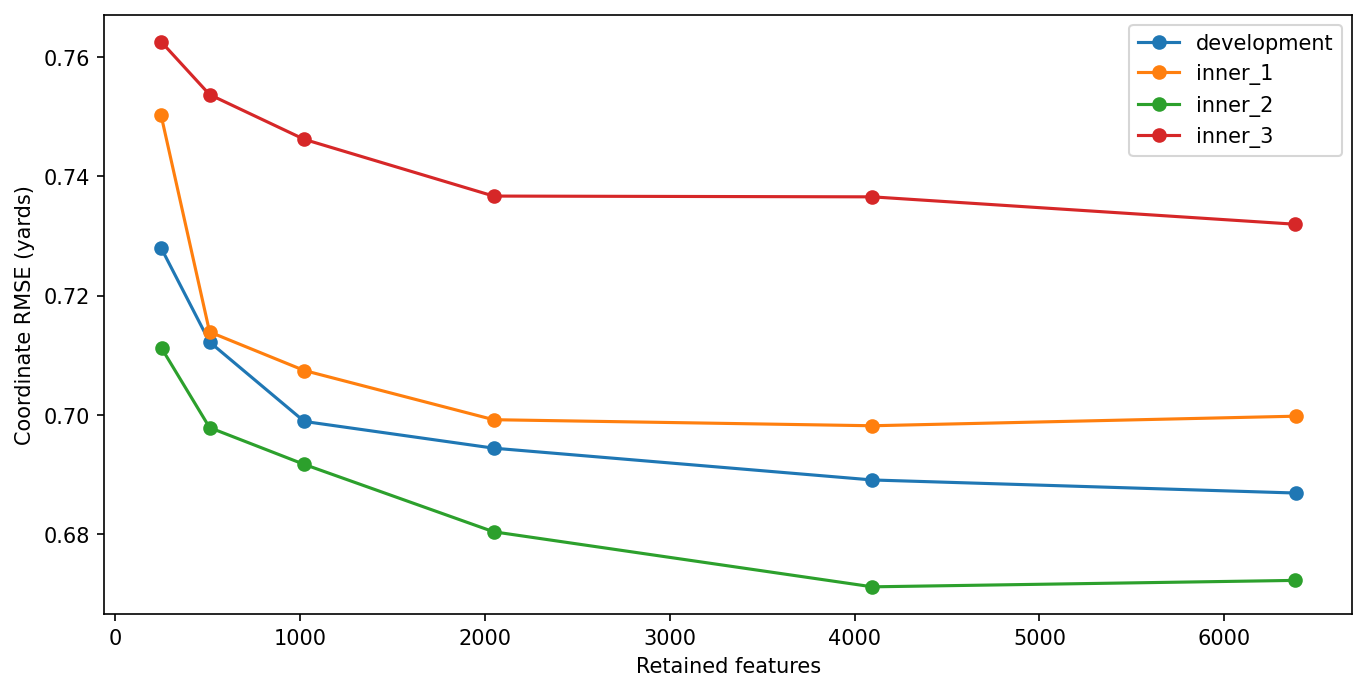

,from,to,rmse_change,paired_game_ci95
0,budget_512,budget_1024,-0.01331,"[-0.018745604610688655, -0.007259463308145274]"
1,budget_1024,budget_2048,-0.00448,"[-0.01307071876733599, 0.0034492377425701937]"
2,budget_2048,budget_4096,-0.00533,"[-0.009319717307067668, -0.001471844640509794]"
3,budget_4096,budget_8192,-0.00219,"[-0.006079650721299882, 0.0019902374250122972]"


In [3]:
if budget:
    widths = pd.DataFrame(
        [
            {
                "fold": fold["fold"]["name"],
                "model": row["model"],
                "feature_count": row["feature_count"],
                "coordinate_rmse_yards": row["coordinate_rmse_yards"],
            }
            for fold in [*budget["inner_folds"], budget]
            for row in fold["models"]
        ]
    )
    display(widths.pivot(index="model", columns="fold", values="coordinate_rmse_yards").round(5))
    display(pd.Series(budget["inner_scores"], name="Pooled inner-fold RMSE").sort_values())
    interactive(
        px.line(
            widths,
            x="feature_count",
            y="coordinate_rmse_yards",
            color="fold",
            markers=True,
            title="Marginal value of a wider screened representation",
            labels={"feature_count": "Retained features", "coordinate_rmse_yards": "RMSE (yards)"},
        )
    )
    fig, ax = plt.subplots(figsize=(9, 4.5), layout="constrained")
    for name, rows in widths.groupby("fold", sort=True):
        ax.plot(rows.feature_count, rows.coordinate_rmse_yards, marker="o", label=name)
    ax.set_xlabel("Retained features")
    ax.set_ylabel("Coordinate RMSE (yards)")
    ax.legend()
    static(fig)
    if attribution:
        display(pd.DataFrame(attribution["development"]["incremental_width"]).round(5))
else:
    display(Markdown("Width comparisons are incomplete until every fold has a verified result."))

## 3 · Which families help, and which disappoint?

Strict removals delete a family from the 250-feature union, refit with identical settings, and add no replacement columns. A positive RMSE change indicates useful conditional information. The positional linear fallback uses another estimator and is reported separately.

Reachability and role-specific destination geometry were consistently useful in the chronological experiments. Route descriptors, role-gated terms, and metadata showed more mixed or small effects. A weak sequential linear correction can still help a nonlinear model; every conclusion must identify its comparator.

In [4]:
if ablation:
    rows = []
    for fold in [*ablation["inner_folds"], ablation]:
        reference = next(
            r["coordinate_rmse_yards"] for r in fold["models"] if r["model"] == "all_engineered"
        )
        for row in fold["models"]:
            if row["model"].startswith("without_"):
                rows.append(
                    {
                        "fold": fold["fold"]["name"],
                        "removed": row["model"].removeprefix("without_"),
                        "rmse_change": row["coordinate_rmse_yards"] - reference,
                    }
                )
    removals = pd.DataFrame(rows)
    display(removals.pivot(index="removed", columns="fold", values="rmse_change").round(5))
    interactive(
        px.bar(
            removals,
            x="removed",
            y="rmse_change",
            color="fold",
            barmode="group",
            title="Strict family removals; fixed estimator",
            labels={"rmse_change": "RMSE increase after removal (yards)"},
        )
    )
    display(
        pd.DataFrame(ablation["models"])[["model", "feature_count", "coordinate_rmse_yards"]].round(
            5
        )
    )

fold,development,inner_1,inner_2,inner_3
removed,,,,
graph_pool,0.00218,0.00181,0.00254,0.00301
matched_history,0.00316,0.00264,0.00289,0.00194
player_metadata,0.00113,0.00155,0.00141,0.00122
reachability,0.00340,0.00694,0.00419,0.01596
role_destination,0.01008,0.00563,0.00981,0.00378
role_response,0.00011,0.00107,0.00256,-0.00168
route_representation,0.00201,0.00266,-0.00220,-0.00035


,model,feature_count,coordinate_rmse_yards
0,all_engineered,250,0.72802
1,without_reachability,238,0.73142
2,without_role_response,241,0.72813
3,without_route_representation,229,0.73003
4,without_role_destination,229,0.73810
5,without_graph_pool,228,0.73020
6,without_matched_history,238,0.73117
7,without_player_metadata,229,0.72915
8,robust_linear,212,0.84097


### Explain the wider representation separately

The permutation study describes the full screened budget with available metadata. The availability-profile comparisons then test whether metadata or optional telemetry is needed. The next section refits removals from the selected metadata-free inference profile.

Family permutations shuffle complete trajectories within role and forecast horizon, preserve exact forecast-frame alignment, and hold the physical baseline fixed. Five seeds measure shuffle sensitivity. Their range is **not a confidence interval**. Permutation measures reliance by this model, not causal importance; correlated families may substitute for each other.

Fresh fixed-capacity refits remove body/position metadata and then all optional metadata/telemetry dependencies. Historical residual priors remain eligible in both profiles; a separate raw-input stress test clears their lookups. These checks distinguish refitted availability profiles from cold-history behavior.

**Inner-fold choice:** budget_8192 · 6,385 retained columns

,family,feature_count,rmse_increase_mean,rmse_increase_min,rmse_increase_max
10,multiscale,468,0.11583,0.10690,0.12186
15,reachability,45,0.11575,0.11093,0.12345
3,forecast_interactions,449,0.04434,0.03964,0.05236
17,role_destination,92,0.04403,0.04225,0.04562
16,robust_history,516,0.02752,0.02632,0.02937
18,role_response,798,0.02200,0.02012,0.02345
4,graph_pool,640,0.02143,0.01798,0.02323
8,matched_history,650,0.01937,0.01639,0.02250
6,history_summaries,1357,0.01709,0.01582,0.01833
11,nonlinear,78,0.01002,0.00743,0.01195


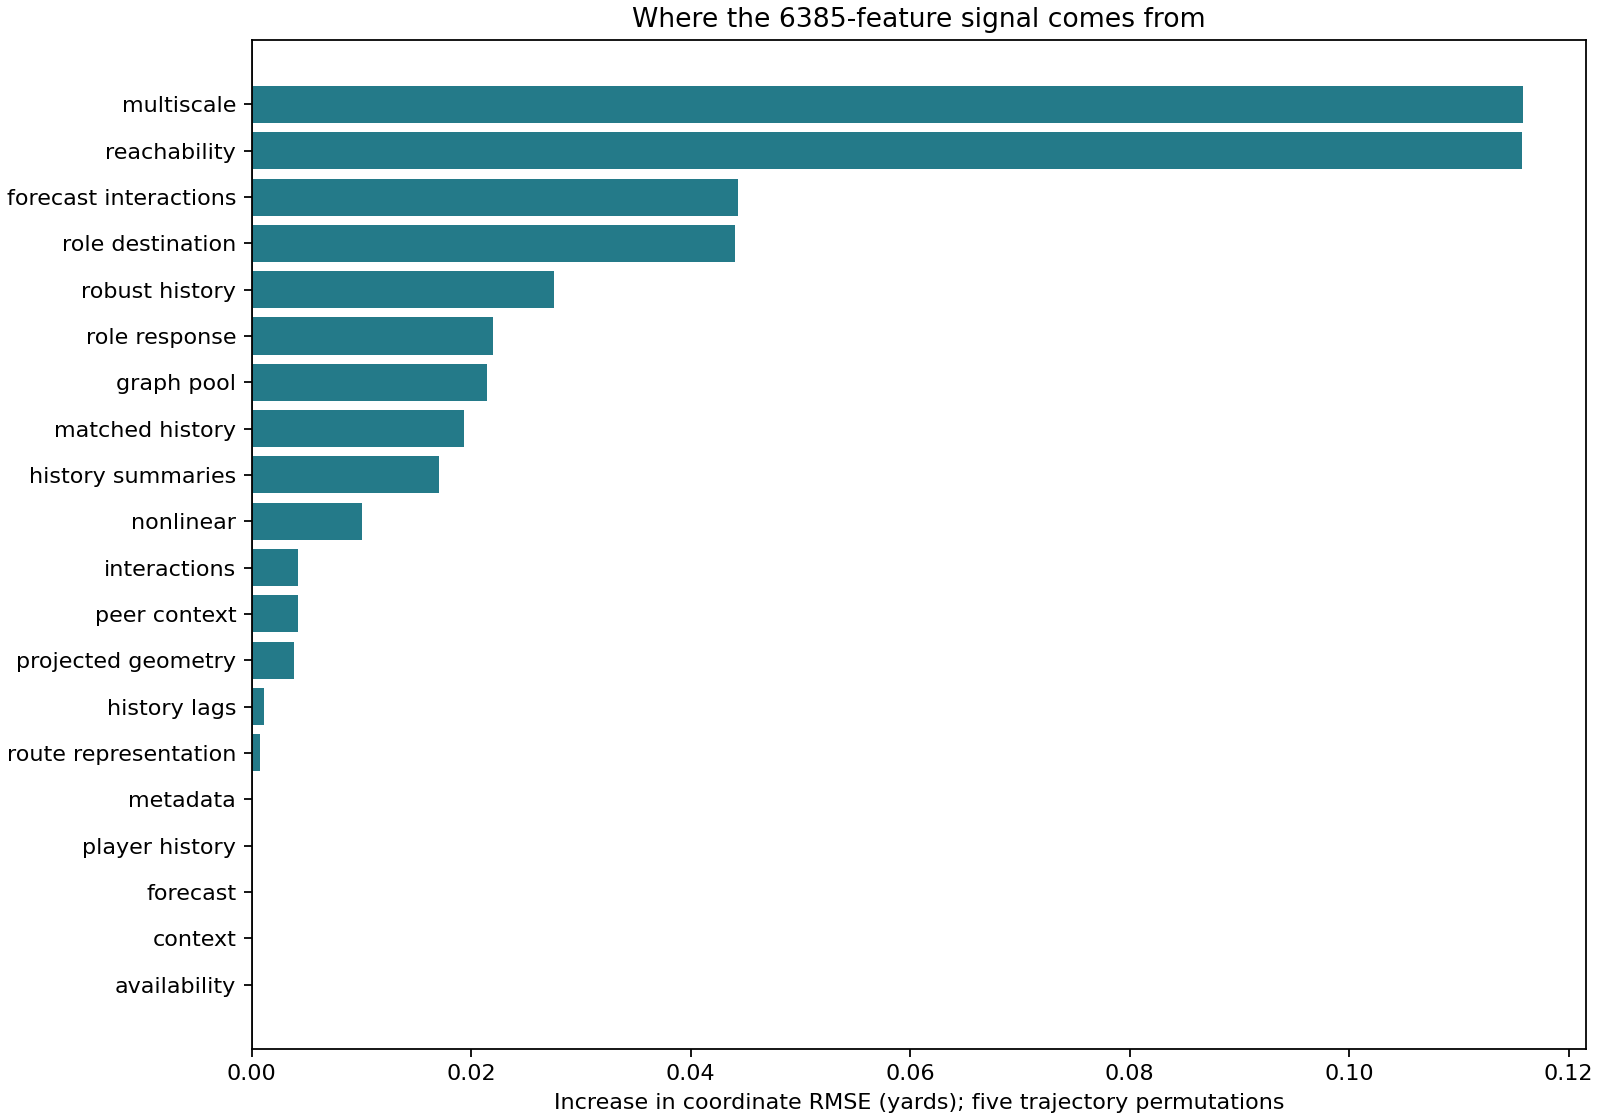

,fold,model,feature_count,coordinate_rmse_yards,delta_vs_full_ci95
0,inner_1,without_metadata,6309,0.69851,"[-0.003943256607213366, 0.001958164574968891]"
1,inner_1,without_optional_inputs,5572,0.70658,"[-0.0009194239108966938, 0.015258504177832543]"
2,inner_2,without_metadata,6310,0.67209,"[-0.0023451721066467925, 0.001863894257339764]"
3,inner_2,without_optional_inputs,5571,0.68160,"[0.002612924250761442, 0.015733681681925165]"
4,inner_3,without_metadata,6311,0.73530,"[0.0003200678747442232, 0.00650222946110432]"
5,inner_3,without_optional_inputs,5571,0.75652,"[0.017474456974934473, 0.03155202839222658]"
6,development,without_metadata,6308,0.68805,"[-0.0015598898023053808, 0.003929565507161633]"
7,development,without_optional_inputs,5572,0.69396,"[-0.0005274971402717821, 0.014685377619688996]"


In [5]:
if attribution:
    display(
        Markdown(
            f"**Inner-fold choice:** {attribution['selected_model']} · "
            f"{attribution['development']['feature_count']:,} retained columns"
        )
    )
    dependence = pd.DataFrame(attribution["development"]["permutation"])
    display(
        dependence.drop(columns="seed_changes")
        .sort_values("rmse_increase_mean", ascending=False)
        .round(5)
    )
    interactive(
        px.bar(
            dependence.sort_values("rmse_increase_mean"),
            x="rmse_increase_mean",
            y="family",
            orientation="h",
            title="Conditional reliance of the selected wide representation",
            labels={"rmse_increase_mean": "Development RMSE increase (yards)"},
        )
    )
    figure = ROOT / "artifacts/feature_attribution/figure.png"
    if not figure.exists():
        figure = PUBLISHED / "feature_attribution.png"
    if figure.exists():
        display(Image(filename=str(figure)))
    display(
        pd.DataFrame(
            [
                {
                    "fold": fold["fold"],
                    **{
                        key: row[key]
                        for key in [
                            "model",
                            "feature_count",
                            "coordinate_rmse_yards",
                            "delta_vs_full_ci95",
                        ]
                    },
                }
                for fold in [*attribution["inner_folds"], attribution["development"]]
                for row in fold["omissions"]
            ]
        ).round(5)
    )

### Refit group removals on the current wide predictor

These refits use the selected wide availability profile before lossless pruning. Twelve disjoint groups cover all 20 feature families. Each removal preserves the physical baseline and estimator settings and adds no replacement columns. An already absent group is explicitly marked as a structural control, with no fabricated fit.

These are column-group ablations: derived information in other families can remain. Dropping direct history summaries, for example, does not remove every forecast interaction derived from motion.

Positive RMSE changes mean the group supplies useful conditional information. Negative changes identify possible simplifications. Group effects are not additive because other features can substitute. The [predeclared protocol](../docs/WIDE_ABLATION_PROTOCOL.md) keeps the gate open if an omission improves pooled inner RMSE by at least 0.5% without costing any fold more than 1%. Development intervals describe paired game uncertainty and do not choose the representation.


fold,development,inner_1,inner_2,inner_3
group,,,,
arrival_feasibility,0.00562,0.00780,0.00922,0.01431
body_position_metadata,0.00000,0.00000,0.00000,0.00000
coverage_geometry,0.00376,0.00411,0.00301,0.00256
destination_coupling,0.00066,0.00381,0.00672,-0.00074
forecast_crosses,0.00148,-0.00352,-0.00114,-0.00169
historical_priors,0.00000,0.00180,0.00000,0.00000
multiscale_transforms,0.00537,0.01075,0.00619,0.00530
observed_histories,0.00060,-0.00393,-0.00116,-0.00284
player_set_pools,0.00376,0.00175,0.00181,0.00154


,group,pooled_coordinate_rmse_yards,pooled_rmse_change,pooled_relative_gain,inner_relative_costs
0,observed_histories,0.69977,-0.00283,0.00403,"[-0.005622759241483366, -0.0017242666841759124..."
1,multiscale_transforms,0.71039,0.00779,-0.01109,"[0.015395155702376817, 0.009216679489964852, 0..."
2,coverage_geometry,0.70592,0.00332,-0.00472,"[0.00588976268759267, 0.004475855227954684, 0...."
3,forecast_crosses,0.70031,-0.00229,0.00326,"[-0.005033898885505317, -0.0017034198903971287..."
4,role_responses,0.70433,0.00172,-0.00245,"[0.0038045643799773377, 0.0003831579642157301,..."
5,arrival_feasibility,0.71285,0.01025,-0.01458,"[0.0111602108265898, 0.013725084992650904, 0.0..."
6,destination_coupling,0.70576,0.00316,-0.00450,"[0.005454693029837143, 0.009994528031024075, -..."
7,player_set_pools,0.70430,0.00170,-0.00242,"[0.002506128023939569, 0.002692739683535672, 0..."
8,route_representation,0.70157,-0.00104,0.00147,"[-0.0012140453216988867, -9.506483572385704e-0..."
9,historical_priors,0.70334,0.00074,-0.00106,"[0.002580379456146087, 0.0, 0.0]"


,group,removed_features,refitted,coordinate_rmse_yards,paired_game_ci95
36,observed_histories,2400,True,0.68865,"[-0.0031931476990260553, 0.004331081943374854]"
37,multiscale_transforms,546,True,0.69342,"[-0.0027418785131480576, 0.01451733895893044]"
38,coverage_geometry,981,True,0.69181,"[0.0004121251944321003, 0.007234879791943121]"
39,forecast_crosses,449,True,0.68953,"[-0.0015425674382849974, 0.004666916533613116]"
40,role_responses,798,True,0.68832,"[-0.0038707792077039118, 0.004838864043017319]"
41,arrival_feasibility,45,True,0.69367,"[-0.0014576119630118455, 0.012759526022733]"
42,destination_coupling,92,True,0.68871,"[-0.002353380942828934, 0.003935049272827139]"
43,player_set_pools,640,True,0.69182,"[-0.00046383167474677576, 0.008762848220384204]"
44,route_representation,320,True,0.69192,"[0.0009396213433914197, 0.007160200646791026]"
45,historical_priors,10,True,0.68805,"[0.0, 0.0]"


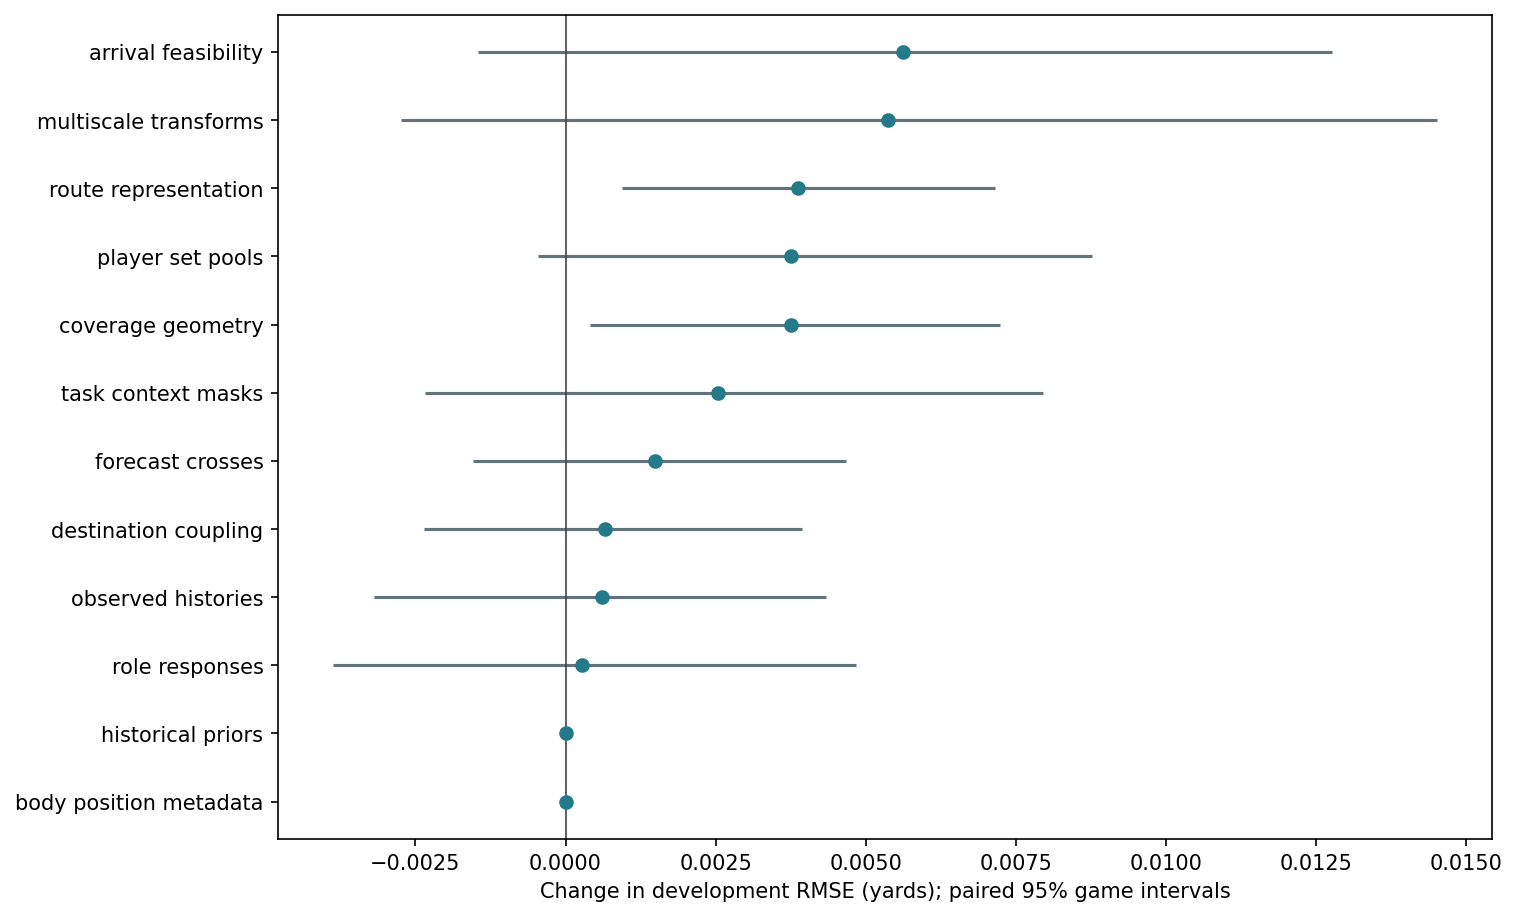

In [6]:
if wide_ablation:
    wide_rows = pd.DataFrame(
        [
            {"fold": fold["fold"], **row}
            for fold in [*wide_ablation["inner_folds"], wide_ablation["development"]]
            for row in fold["models"]
        ]
    )
    display(wide_rows.pivot(index="group", columns="fold", values="rmse_change").round(5))
    display(pd.DataFrame(wide_ablation["pooled_comparisons"]).round(5))
    development_removals = wide_rows[wide_rows.fold.eq("development")].copy()
    display(
        development_removals[
            ["group", "removed_features", "refitted", "coordinate_rmse_yards", "paired_game_ci95"]
        ].round(5)
    )
    interactive(
        px.bar(
            wide_rows,
            x="group",
            y="rmse_change",
            color="fold",
            barmode="group",
            title="Strict removals from the actual wide availability profile",
            labels={"rmse_change": "RMSE change after removal (yards)"},
        )
    )
    ordered = development_removals.sort_values("rmse_change")
    fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
    positions = range(len(ordered))
    ax.hlines(
        positions,
        [bounds[0] for bounds in ordered.paired_game_ci95],
        [bounds[1] for bounds in ordered.paired_game_ci95],
        color="#64737A",
        linewidth=1.5,
    )
    ax.scatter(ordered.rmse_change, positions, color="#247A89", zorder=3)
    ax.set_yticks(positions, labels=ordered.group.str.replace("_", " "))
    ax.axvline(0, color="#444444", linewidth=0.8)
    ax.set_xlabel("Change in development RMSE (yards); paired 95% game intervals")
    static(fig)
else:
    display(
        Markdown("Current wide-profile group refits are still required before feature closure.")
    )

### Test whether two small simplifications work together

Removing direct observed-history columns and removing generic forecast crosses each slightly improved all three inner folds. Their individual gains were below the recorded 0.5% threshold. One additional experiment removes both groups together, preserving every other column and the fixed estimator settings.

This tests whether the small gains accumulate. It does not remove all motion or horizon information: derived features in the remaining families still express both. The combined omission keeps the gate open if pooled inner RMSE improves by at least 0.5% and no inner fold costs more than 1%. Development remains descriptive. See the committed [protocol](../docs/SIMPLIFICATION_PROTOCOL.md).


The completed combined omission changes pooled inner RMSE from **0.7026010 to 0.7014072**, a **0.170% improvement**. Fold changes are −0.298%, +0.324%, and −0.399%. The gain is below the predeclared threshold and is not consistent across time, so it does not justify reopening the feature search.

In [7]:
if simplification:
    comparison_rows = []
    for fold in [*simplification["inner_folds"], simplification["development"]]:
        before = fold["reference"]["coordinate_rmse_yards"]
        after = fold["metrics"]["coordinate_rmse_yards"]
        comparison_rows.append(
            {
                "fold": fold["fold"],
                "parent_columns": fold["parent_feature_count"],
                "retained_columns": fold["feature_count"],
                "parent_rmse": before,
                "combined_omission_rmse": after,
                "rmse_change": after - before,
                "paired_game_ci95": fold["paired_game_ci95"],
            }
        )
    display(pd.DataFrame(comparison_rows).round(5))
    display(pd.Series(simplification["decision"], name="Combined-omission decision"))
else:
    display(Markdown("The targeted combined-omission test is required before feature closure."))

,fold,parent_columns,retained_columns,parent_rmse,combined_omission_rmse,rmse_change,paired_game_ci95
0,inner_1,6309,3459,0.69851,0.69643,-0.00208,"[-0.010892889291622024, 0.0052494938814128716]"
1,inner_2,6310,3460,0.67209,0.67427,0.00218,"[-0.0026733047831711014, 0.006583379185786912]"
2,inner_3,6311,3459,0.73530,0.73236,-0.00293,"[-0.007750302359054395, 0.0010730176023987972]"
3,development,6308,3459,0.68805,0.68995,0.00190,"[-0.002015813096188218, 0.006733401061999799]"


pooled_reference_rmse_yards                                                          0.702601
pooled_candidate_rmse_yards                                                          0.701407
pooled_relative_gain                                                                 0.001699
inner_relative_costs                        [-0.0029771162207516966, 0.003242130174469171,...
requires_smaller_representation_followup                                                False
minimum_gain_to_reopen                                                                  0.005
maximum_fold_cost                                                                        0.01
selection_scope                             Three chronological inner folds; development e...
Name: Combined-omission decision, dtype: object

## 4 · Broad feature coverage with explicit prediction-time boundaries

The catalogs cover motion, landing geometry, lags, multiscale trends and volatility, robust path distributions, matched opponent/receiver histories, relative ranks, nonlinear and role-conditioned crosses, arrival feasibility, geometric player-set pools, role-specific destinations, and training-only route representations.

Player/role residual histories use **strictly earlier game dates**: the entire current date is excluded, smoothing supports sparse players, and evaluation histories are frozen from training. Route components and prototypes are fitted separately inside each training fold. Post-throw coordinates, future game results, full-season target averages, and unverified external ratings cannot enter prediction inputs.

In [8]:
if research:
    families = pd.DataFrame(research["families"])
    display(families[["stage", "family", "candidates", "nonconstant", "constant_or_near_constant"]])
    display(
        Markdown(
            f"**{research['candidate_features']:,} candidates; "
            f"{int(families.nonconstant.sum()):,} nonconstant** on development-training rows. "
            "Eligibility alone does not prove predictive value."
        )
    )
    interactive(
        px.bar(
            families,
            x="candidates",
            y="family",
            color="stage",
            orientation="h",
            title="Candidate families and search coverage",
        )
    )
    display(
        pd.DataFrame(
            [
                {
                    "stage": row["stage"],
                    "model": row["model"],
                    "all_three_folds": len(row["all_three_folds"]),
                    "any_fold": row["selected_in_any_fold"],
                    "pairwise_jaccard": row["pairwise_jaccard"],
                }
                for row in research["stability"]
            ]
        )
    )

,stage,family,candidates,nonconstant,constant_or_near_constant
0,research,availability,31,16,15
1,research,context,12,7,5
2,research,forecast,6,6,0
3,research,forecast_interactions,462,456,6
4,research,history_lags,560,558,2
5,research,history_summaries,1568,1568,0
6,research,interactions,204,189,15
7,research,multiscale,504,504,0
8,research,nonlinear,84,78,6
9,research,player_history,10,10,0


**7,999 candidates; 6,875 nonconstant** on development-training rows. Eligibility alone does not prove predictive value.

,stage,model,all_three_folds,any_fold,pairwise_jaccard
0,research,plus_interactions,23,41,"[0.6, 0.5609756097560976, 0.9393939393939394]"
1,research,plus_remaining_history,5,60,"[0.0847457627118644, 0.10344827586206896, 0.88..."
2,research,plus_multiscale,23,42,"[0.5609756097560976, 0.6, 0.8823529411764706]"
3,research,plus_nonlinear,22,42,"[0.5609756097560976, 0.5238095238095238, 0.939..."
4,research,plus_role_response,24,39,"[0.7297297297297297, 0.6410256410256411, 0.828..."
5,research,plus_projected_geometry,24,41,"[0.6410256410256411, 0.6, 0.8823529411764706]"
6,research,plus_player_history,10,10,"[1.0, 1.0, 1.0]"
7,research,plus_balanced,43,85,"[0.5802469135802469, 0.5421686746987951, 0.828..."
8,research,balanced_without_interactions,36,72,"[0.5652173913043478, 0.5428571428571428, 0.830..."
9,research,balanced_without_multiscale,38,75,"[0.5915492957746479, 0.527027027027027, 0.8387..."


### Stability can be strong at the family level and weak at the column level

Combined context improved all three chronological folds. Individual selected columns overlap less because many lagged and gated variables express related signals. We report that overlap. PCA names do not guarantee identical axes across folds. This study has one labelled season: it does not establish across-season stability.

The sequential 186-feature predictor is an interpretable intermediate. Its permutation report explains that fit, not the current joint linear model or the wider tree.

In [9]:
if research:
    fold_results = pd.DataFrame(research["fold_results"])
    chosen = fold_results.loc[
        ((fold_results.stage == "research") & (fold_results.model == "plus_balanced"))
        | ((fold_results.stage == "context") & (fold_results.model == "plus_context"))
        | ((fold_results.stage == "representation") & (fold_results.model == "plus_representation"))
    ]
    display(
        chosen[
            [
                "stage",
                "fold",
                "training_games",
                "validation_games",
                "coordinate_rmse_yards",
                "improvement_vs_parent_percent",
            ]
        ].round(5)
    )
    if importance:
        display(
            pd.DataFrame(importance["rows"])[
                ["family", "retained_features", "mean_rmse_increase_yards", "shuffle_sd_yards"]
            ].round(5)
        )
if gate:
    stability = gate["used_feature_stability"]
    display(
        Markdown(
            f"**Actual tree use:** {stability['count_used_in_all_inner_fits']:,} definitions "
            "appear in all three inner fits. This differs from merely surviving a broad screen."
        )
    )
    display(pd.DataFrame(stability["pairwise_jaccard"]).round(3))
    display(Markdown(stability["caveat"]))

,stage,fold,training_games,validation_games,coordinate_rmse_yards,improvement_vs_parent_percent
2,research,inner_1,94,41,0.91069,3.51967
19,research,inner_2,135,28,0.86976,3.80984
38,research,inner_3,163,29,0.92245,3.43606
57,context,inner_1,94,41,0.87007,4.46008
71,context,inner_2,135,28,0.83759,3.69920
83,context,inner_3,163,29,0.87833,4.78236
96,representation,inner_1,94,41,0.89359,1.87743
106,representation,inner_2,135,28,0.85609,1.57157
114,representation,inner_3,163,29,0.90731,1.64047


,family,retained_features,mean_rmse_increase_yards,shuffle_sd_yards
0,forecast_interactions,23,0.10857,0.00435
1,history_lags,23,0.09602,0.00193
2,reachability,12,0.06411,0.00251
3,multiscale,6,0.04168,0.00116
4,role_response,9,0.02636,0.00626
5,matched_history,12,0.02358,0.00133
6,nonlinear,10,0.02217,0.00150
7,interactions,3,0.01955,0.00094
8,history_summaries,30,0.01731,0.00034
9,peer_context,12,0.00865,0.00056


**Actual tree use:** 375 definitions appear in all three inner fits. This differs from merely surviving a broad screen.

,first,second,jaccard
0,inner_1,inner_2,0.308
1,inner_1,inner_3,0.315
2,inner_2,inner_3,0.361


Shared definitions; learned route component axes can rotate between fits.

## 5 · Carry the validated features into actual inference

The joint linear experiment first tests whether refitting all coefficients recovers signal lost by sequential corrections. The portable tree handoff then reuses the already fitted, fixed-capacity feature trees. It chooses between metadata-free availability profiles on the inner folds, converts their numerical splits to a standalone representation, and drops columns never used by a split. Prediction parity is required after this lossless pruning. No additional model tuning occurs.

Raw inference must reproduce the cached-feature score on **every development frame**. Stress scenarios remove metadata, remove telemetry, and clear player history. Missing required fields select an independently fitted compatible profile. Silent zero filling is not a valid availability fallback.

In [10]:
if joint:
    display(
        pd.DataFrame(joint["models"])[["model", "feature_count", "coordinate_rmse_yards"]].round(5)
    )
    display(pd.Series(joint["inner_scores"], name="Pooled inner-fold RMSE").sort_values())
    display(Markdown(f"**Selected linear profile:** {joint['selected_model']}"))
if inference:
    display(pd.DataFrame(inference["scenarios"]).round(5))
    display(
        Markdown(
            f"**Actual raw-input predictor:** {inference['selected_stage']} / "
            f"{inference['selected_model']} · {inference['retained_features']} features. "
            "Publication verifies source hashes, fitted artifacts, and per-week replay receipts."
        )
    )
else:
    display(Markdown("Full raw-input replay must pass before this path is called validated."))
if input_failure and inference:
    before = pd.DataFrame(input_failure["scenarios"]).set_index("scenario")
    after = pd.DataFrame(inference["scenarios"]).set_index("scenario")
    display(Markdown("**Archived availability failure and the current validated remedy**"))
    display(
        pd.DataFrame(
            {
                "Archived sequential profile RMSE": before.coordinate_rmse_yards,
                "Current profile RMSE": after.coordinate_rmse_yards,
            }
        ).round(5)
    )
    display(
        Markdown(
            "The archived 186-feature profile failed badly when telemetry disappeared. "
            "That result motivated independently fitted availability profiles. "
            "This historical comparison changes both representation and estimator; "
            "the fixed-estimator experiments above establish feature attribution."
        )
    )

,model,feature_count,coordinate_rmse_yards
0,joint_all,247,0.82215
1,joint_without_metadata,236,0.82226
2,joint_positional,212,0.84097


joint_without_metadata    0.808414
joint_all                 0.808488
joint_positional          0.835757
Name: Pooled inner-fold RMSE, dtype: float64

**Selected linear profile:** joint_without_metadata

,scenario,variant,coordinate_rmse_yards,rows,elapsed_seconds
0,complete_inputs,complete_inputs,0.68805,67857,75.74739
1,missing_metadata,complete_inputs,0.68805,67857,75.38032
2,missing_telemetry,without_telemetry,0.69396,67857,75.05751
3,cold_player_history,complete_inputs,0.68805,67857,75.84604


**Actual raw-input predictor:** fixed_tree / budget_8192__without_metadata · 953 features. Publication verifies source hashes, fitted artifacts, and per-week replay receipts.

**Archived availability failure and the current validated remedy**

,Archived sequential profile RMSE,Current profile RMSE
scenario,,
complete_inputs,0.86434,0.68805
missing_metadata,0.97607,0.68805
missing_telemetry,8.15492,0.69396
cold_player_history,0.86843,0.68805


The archived 186-feature profile failed badly when telemetry disappeared. That result motivated independently fitted availability profiles. This historical comparison changes both representation and estimator; the fixed-estimator experiments above establish feature attribution.

### Inspect one play without selecting a flattering example

The example is the first development play by game/play identifier, showing up to three requested players in identifier order. Selection does not use prediction error. Solid dots mark the throw. The embedded figure uses the current validated research predictor. Regenerating this particular figure requires private tracking; the full quantitative comparisons above also work from the published aggregates.

The physical-baseline curve shows what the learned correction changes. The per-player table can show improvements or regressions; this single example does not replace the full-game attribution evidence.


{"timestamp": "2026-09-09T01:53:04.243+00:00", "run_id": "20260909T015249Z-fa702e96", "event": "heartbeat", "elapsed_seconds": 15.001, "status": "running"}


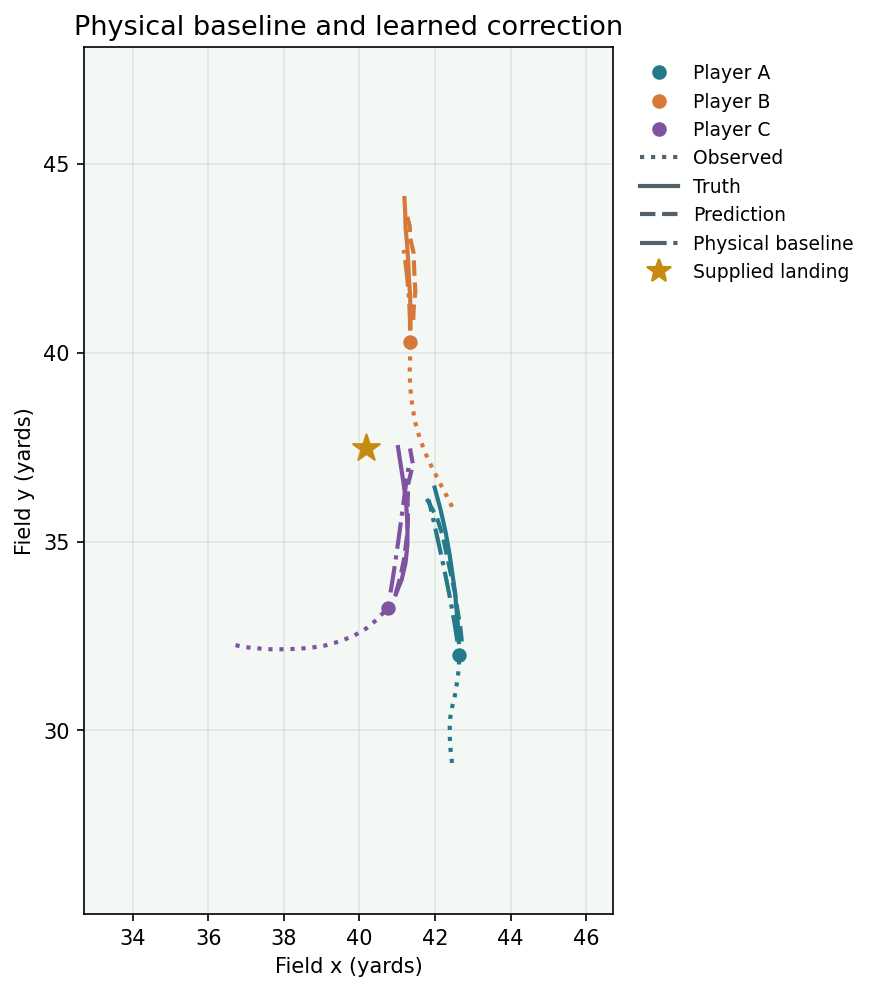

,Player,Role
0,A,Defensive Coverage
1,B,Defensive Coverage
2,C,Targeted Receiver


,Player,Physical baseline RMSE,Engineered RMSE
0,A,0.15883,0.10864
1,B,0.59430,0.18271
2,C,0.19283,0.12948


**Displayed predictor:** budget_8192__without_metadata · first development game/play: 2023120400/107.

In [11]:
from nfl_trajectory.research_visuals import load_development_example

example = load_development_example(ROOT)
if example:
    static(example.static_figure)
    interactive(example.interactive_figure)
    display(example.roles)
    display(example.metrics.round(5))
    display(
        Markdown(
            f"**Displayed predictor:** {example.selected_model} · "
            f"first development game/play: {example.game_id}/{example.play_id}."
        )
    )
else:
    display(Markdown("The canonical executed notebook contains the private-data example figure."))

### Verify the organizer interface on its own unlabelled sample

The organizer sends one play at a time and expects finite x/y predictions in the requested order. The test uses checksum-verified organizer source and sample inputs, checks package/standalone parity for every callback, and verifies Parquet row identifiers. Output stays in the isolated quality directory.

A pass establishes interface compatibility. It gives no accuracy score, across-season performance result, or competition submission.

In [12]:
if gateway:
    display(
        pd.DataFrame(
            [
                {
                    key: gateway[key]
                    for key in [
                        "official_gateway_status",
                        "selected_model",
                        "retained_features",
                        "sample_rows",
                        "plays",
                        "sample_calendar_years",
                        "callback_seconds_median",
                        "callback_seconds_p95",
                        "callback_seconds_max",
                        "standalone_prediction_parity",
                        "labels_available",
                        "competition_submission",
                    ]
                }
            ]
        )
    )
else:
    display(Markdown("Organizer gateway validation is not yet recorded in this checkout."))

,official_gateway_status,selected_model,retained_features,sample_rows,plays,sample_calendar_years,callback_seconds_median,callback_seconds_p95,callback_seconds_max,standalone_prediction_parity,labels_available,competition_submission
0,passed,budget_8192__without_metadata,953,5837,143,"[2024, 2025]",0.537614,0.588182,0.644177,exact for every sample callback,False,not_run


### Diagnose the current predictor by role and requested horizon

These slices use the **same portable predictor that passed raw replay and the gateway**. ADE measures displacement throughout the trajectory; FDE measures its final requested frame. Horizons group complete trajectories, preserving the meaning of FDE. Error shares show where remaining squared error is concentrated. These are descriptive development diagnostics, with no holdout or subgroup tuning.

,dimension,value,rows,games,coordinate_rmse_yards,ade_frame_weighted_yards,fde_trajectory_weighted_yards,p95_displacement_yards,squared_error_share_percent
0,role,Defensive Coverage,48729,32,0.7605,0.6316,1.1834,2.3280,87.7360
1,role,Targeted Receiver,19128,32,0.4538,0.4157,0.6758,1.3425,12.2640
2,requested_horizon,up to 1 s,21313,32,0.2395,0.2471,0.4999,0.6987,3.8071
3,requested_horizon,1–2 s,31749,32,0.5731,0.5328,1.2125,1.7465,32.4640
4,requested_horizon,2–3 s,12568,30,1.1326,1.0726,2.5813,3.4801,50.1888
5,requested_horizon,over 3 s,2227,11,1.3976,1.3760,3.2487,4.4485,13.5402


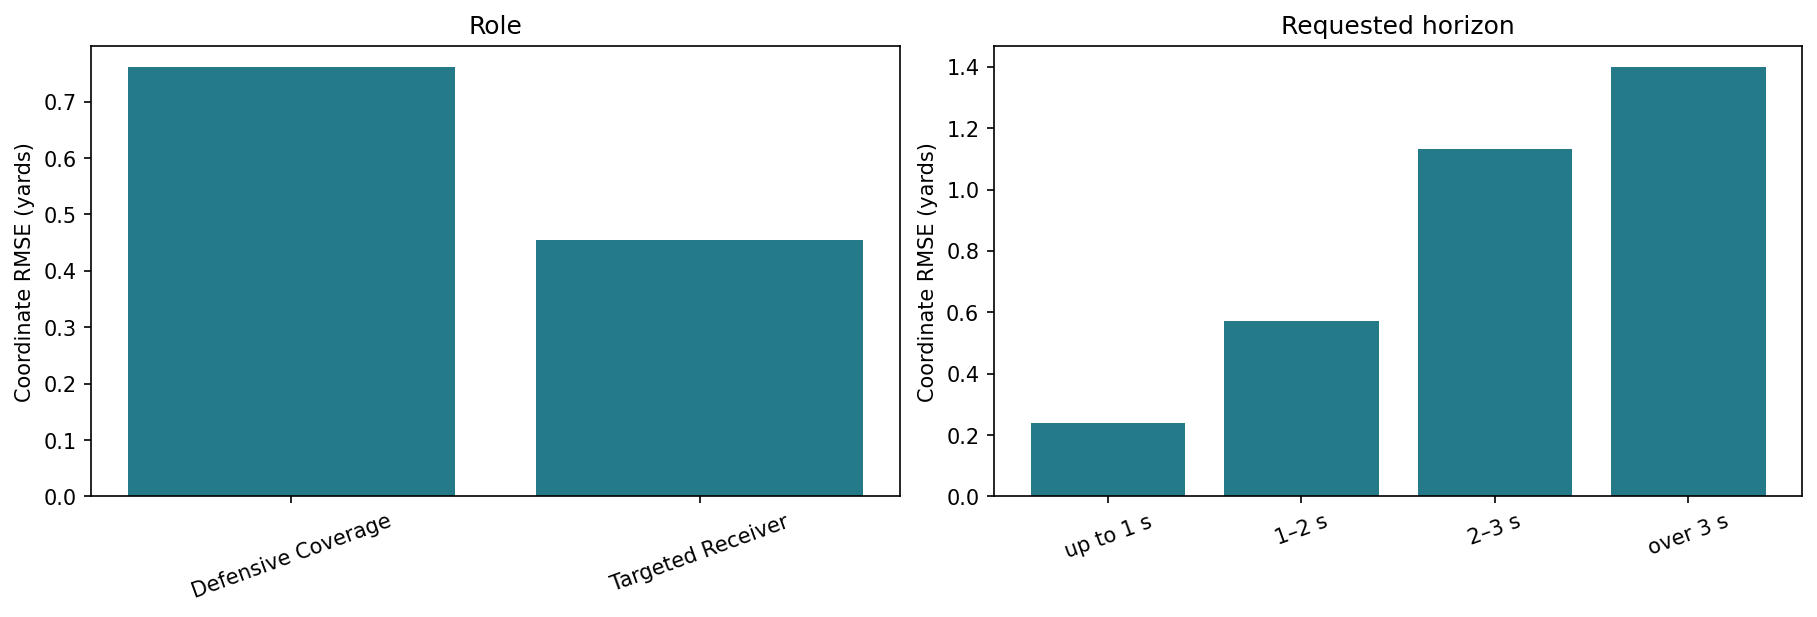

In [13]:
if diagnostics:
    slices = pd.DataFrame(diagnostics["slices"])
    display(
        slices[
            [
                "dimension",
                "value",
                "rows",
                "games",
                "coordinate_rmse_yards",
                "ade_frame_weighted_yards",
                "fde_trajectory_weighted_yards",
                "p95_displacement_yards",
                "squared_error_share_percent",
            ]
        ].round(4)
    )
    chart = px.bar(
        slices,
        x="value",
        y="coordinate_rmse_yards",
        facet_col="dimension",
        color="dimension",
        labels={"value": "", "coordinate_rmse_yards": "Coordinate RMSE (yards)"},
        title="Remaining error in the current validated representation",
    )
    chart.update_xaxes(matches=None)
    interactive(chart)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
    for ax, dimension in zip(axes, ["role", "requested_horizon"], strict=True):
        part = slices.loc[slices.dimension.eq(dimension)]
        ax.bar(part.value, part.coordinate_rmse_yards, color="#247A89")
        ax.set_title(dimension.replace("_", " ").capitalize())
        ax.set_ylabel("Coordinate RMSE (yards)")
        ax.tick_params(axis="x", labelrotation=20)
    static(fig)

## 6 · Preserve the original research lesson

Landing ridge initially reached 0.9269 RMSE versus 0.9896 for role-conditioned motion. The broader interaction challenger replaced 23 of the 64 landing columns. Its weaker score confounded adding interactions with removing useful terms. This motivated nested additions, chronological inner selection, and strict removals.

These original diagnostics explain the research design; they are not the latest performance claim.

In [14]:
from nfl_trajectory.research import error_budget

display(
    pd.DataFrame(feature_summary["models"])[
        [
            "model",
            "selected_features",
            "coordinate_rmse_yards",
            "ade_frame_weighted_yards",
            "fde_trajectory_weighted_yards",
            "p95_displacement_yards",
        ]
    ].round(4)
)
display(
    pd.DataFrame(
        {
            "Removed landing feature": selection["removed_from_landing"],
            "Added interaction feature": selection["added_by_interaction"],
        }
    )
)
roles = error_budget(feature_summary, "role")
horizons = error_budget(feature_summary, "forecast_second")
display(roles.round(3))
display(horizons.round(3))
interactive(
    px.bar(
        horizons,
        x="value",
        y="squared_error_share_percent",
        title="Original landing-model error budget",
        labels={
            "value": "Forecast second",
            "squared_error_share_percent": "Squared error share (%)",
        },
    )
)

,model,selected_features,coordinate_rmse_yards,ade_frame_weighted_yards,fde_trajectory_weighted_yards,p95_displacement_yards
0,landing_ridge,64,0.9269,0.8254,1.4168,2.7538
1,interaction_ridge,64,0.9422,0.8438,1.4309,2.8081
2,motion_ridge,64,0.9467,0.8545,1.4686,2.8071
3,role_ridge,6,0.9896,0.8847,1.5057,3.0028
4,constant_velocity,1,1.7225,1.5142,2.8696,5.4431


,Removed landing feature,Added interaction feature
0,fraction__lateral_speed,fraction__receiver1__dx
1,lag07__ball_ux,fraction__teammate6__dx
2,lag08__ball_ux,fraction_squared__receiver1__dx
3,lag09__ball_ux,passer1__closest_distance
4,lag10__ball_ux,passer1__distance
5,lag12__dir_sin,passer1__dx
6,lag13__dir_sin,receiver1__dx
7,lag14__dir_sin,teammate5__dx
8,lag15__dir_sin,teammate6__dx
9,lag16__dir_sin,time__opponent1__closest_time


,value,rows,coordinate_rmse_yards,row_share_percent,squared_error_share_percent
0,Defensive Coverage,48729,1.032,71.811,89.048
1,Targeted Receiver,19128,0.578,28.189,10.952


,value,rows,coordinate_rmse_yards,row_share_percent,squared_error_share_percent
0,1,49613,0.439,73.114,16.426
1,2,15009,1.325,22.119,45.197
2,3,3108,2.563,4.580,35.019
3,4,127,3.926,0.187,3.358


## 7 · Feature engineering is a completion gate

The official metric is

$$\mathrm{RMSE}=\sqrt{\frac{\sum_{i=1}^{N}[(\hat{x}_i-x_i)^2+(\hat{y}_i-y_i)^2]}{2N}}.$$

Frames have equal coordinate weight. Game-cluster bootstraps preserve within-game dependence. Paired intervals describe uncertainty on these development games; they do not erase repeated research decisions or establish multi-season generalization.

Closing the gate requires justified coverage, training-only screening, leakage tests, fixed-estimator improvements, ablations, stability, robust inference, and diminished marginal gains from realistic extensions. External team/coaching ratings lack a verified prediction-time join here. Train-only route representations are implemented; a pretrained football foundation model is not.

The decision below applies the tolerances recorded in the [research plan](../docs/RESEARCH_PLAN.md) before full-pool results were reviewed. Any failed criterion keeps the gate open. This is a bounded research stopping decision, not a claim that all possible football representations have been invented. Final refitting and the reserved holdout come afterwards. The inference report identifies the actual exported profile and its verified metric; promotion requires raw and standalone parity.

**Closure decision:** the complete group-refit and combined-omission evidence now satisfies every recorded criterion. The final width increment improves pooled inner RMSE by only **0.071%**; the targeted combined omission improves it by **0.170%**, both with mixed folds. This supports diminishing returns within the stated search. The frozen manifest preserves **6,308 refit columns**, while the current trees use **953 inputs**. A future refit must start from the former and receive new validation evidence.

In [15]:
if gate:
    display(pd.DataFrame(gate["checks"]))
    display(pd.DataFrame(gate["coverage"]))
    display(pd.Series(gate["measurements"], name="Stopping evidence"))
    display(
        Markdown(
            f"**Final training ready: {gate['final_training_ready']}.** "
            "The reserved holdout remains unscored in this feature research record."
        )
    )
else:
    display(Markdown("**Gate open:** current completion evidence has not been published."))

,criterion,passed
0,every_catalog_candidate_screened,True
1,complete_eligible_pool_explored,True
2,available_labelled_seasons_represented,True
3,fixed_estimator_gain_in_every_inner_fold,True
4,small_final_width_gain,True
5,metadata_independence,True
6,positional_fallback_remains_strong,True
7,family_removals_and_permutations,True
8,current_profile_group_refits,True
9,no_unresolved_profitable_group_removal,True


,fold,catalog_candidates,screened_candidates,eligible_candidates,pool_candidates,retained_after_redundancy,all_screened,complete_pool
0,inner_1,7999,7999,6866,6866,6386,True,True
1,inner_2,7999,7999,6866,6866,6382,True,True
2,inner_3,7999,7999,6866,6866,6382,True,True
3,development,7999,7999,6875,6875,6385,True,True


all_screened                                                              True
complete_pool                                                             True
scope_verified                                                            True
feature_gains                [0.17218734354569765, 0.15876925461401892, 0.1...
tail_gains                                    [0.0, 0.0, 0.006226186911637899]
pooled_tail_gain                                                      0.000708
metadata_cost                                                         0.000627
positional_cost                                                       0.018632
family_evidence                                                           True
wide_refits_verified                                                      True
unresolved_wide_removals                                                    []
simplification_verified                                                   True
unresolved_simplification                           

**Final training ready: True.** The reserved holdout remains unscored in this feature research record.

## Generate and download your own inference artifact

The switch is off for review and automated publication. Enabling it verifies and exports the current local **research** bundle with its fitted availability fallback. It provides a download and never submits to Kaggle. The exporter loads the current source-verified research profile; it cannot silently advertise another experiment's score.

In [16]:
import base64
import subprocess
import sys

from IPython.display import HTML

GENERATE_EXPORT = False
if GENERATE_EXPORT:
    local_summary = ROOT / "artifacts/research/summary.json"
    if not local_summary.is_file():
        raise FileNotFoundError("Verified local research artifacts are required for an export.")
    requested_model = "research"
    subprocess.run(
        [sys.executable, str(ROOT / "kaggle/export.py"), "--model", requested_model],
        cwd=ROOT,
        check=True,
    )
    export_path = ROOT / "artifacts/kaggle/submission.ipynb"
    payload = base64.b64encode(export_path.read_bytes()).decode("ascii")
    display(
        HTML(
            '<a download="submission.ipynb" href="data:application/x-ipynb+json;base64,'
            + payload
            + '">Download the inference notebook you generated</a>'
        )
    )
else:
    display(
        Markdown(
            "**Export is off.** Set `GENERATE_EXPORT = True` "
            "to build and download your own artifact."
        )
    )

**Export is off.** Set `GENERATE_EXPORT = True` to build and download your own artifact.